___

# <font color= #99C8F5> **Predicción del Tipo de Cambio en Banxico** </font>
#### <font color= #2E9AFE> `Modelos no Lineales para Pronósticos`</font>
<Strong> Daniela De la Torre, Samantha Sánchez, Sofía Maldonado & Viviana Toledo </Strong>

_04/03/2026._

___

# <font color= #99C8F5> **Librerías y Cargado de Datos** </font>

In [1]:
# Generales
import pandas as pd
import banxicoapi
import os
from dotenv import load_dotenv

# Visualización
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Preprocesamiento
import holidays

# Pruebas Estadísticas
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelo
from statsmodels.tsa.statespace.sarimax import SARIMAX

Para iniciar, nos conectaremos a la API del Banco de México (Banxico) y extraeremos los datos del tipo de cambio entre el peso mexicano y el dólar.

In [2]:
# Get the API KEY
load_dotenv()
API_KEY = os.getenv('API_KEY')

# Connect to Banxico using its library
API = banxicoapi.BanxicoApi(API_KEY)

In [3]:
# Seleccionamos los datos que requerimos (Tipo de Cambio entre el peso y el dólar)
series = ["SF43718"]
response = API.get(series)

df = pd.DataFrame(response[0]['datos'])

df.head()

,fecha,dato
0,12/11/1991,3.0735
1,13/11/1991,3.0712
2,14/11/1991,3.0718
3,15/11/1991,3.0684
4,18/11/1991,3.0673


In [4]:
# Renombrar columnas y convertir tipos
df.rename(columns={'fecha':'Fecha','dato':'Valor'}, inplace=True)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')            # Fecha a formato datetime
df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')               # Tipo de dato numérico (float)
df.set_index('Fecha', inplace=True)                                     # Definir la fecha como índice

In [5]:
df.head()

,Valor
Fecha,
1991-11-12,3.0735
1991-11-13,3.0712
1991-11-14,3.0718
1991-11-15,3.0684
1991-11-18,3.0673


# <font color= #99C8F5> **Visualización** </font>

In [6]:
# Index date column
df.index.name = 'Fecha'

# Visualize series
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df.Valor, mode='lines', name='MXN: USD'))

fig.update_layout(
    title='Cambio MXN-USD',
    xaxis_title='Fecha',
    yaxis_title='MXN: USD'
)
fig.show()

Debido a que el cambio de MXN a USD es bastante variable, decidimos filtrar el dataset. Nuestro objetivo es predecir la semana del 04/mar/2026 al 13/mar/2026, tomaremos exclusivamente los **datos del año 2025 y lo que va del 2026**.

In [7]:
# Filter dataset
df = df.loc['2025-01-01':]

# Visualize series
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df.Valor, mode='lines', name='MXN: USD'))

fig.update_layout(
    title='Cambio MXN-USD',
    xaxis_title='Fecha',
    yaxis_title='MXN: USD'
)
fig.show()

# <font color= #99C8F5> **Preprocesamiento** </font>

El banco cierra los días feriados y fines de semana, por lo tanto, no tenemos información de dichos días. Como es relevante saber cómo estos días afectan el tipo de cambio, se plantea crear una variable sintética que señale los días donde hubo un día feriado. Los fines de semana no representan picos o valles significativos, así que no los vamos a considerar en la variable exógena  

In [8]:
# Create dummy variable
df['holiday'] = 0

# Download holidays from library
years = df.index.year.unique()
holidays = holidays.MX(years=years)

# Fill with 1's the holidays
for date in df.index:
    # Day Window
    window = pd.date_range(start=date - pd.Timedelta(days=1),
                           end=date + pd.Timedelta(days=1))

    # Mark as 1 if the day was a holiday
    if any(d in holidays for d in window):
        df.loc[date, 'holiday'] = 1

Ahora, realizaremos un train-test-split del 95% train y 5% test:

In [9]:
# Establish train size
train_size = 0.95
split_index = int(len(df) * train_size)

# Train-Test-Split
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Train Size: {len(train_df)} days\n")
print(f"Test Size: {len(test_df)} days")

Train Size: 279 days

Test Size: 15 days


# <font color= #99C8F5> **Pruebas Estadísticas** </font>

## <font color= #70A9E0> &ensp; • **Estacionariedad** </font>

In [10]:
# ADF Test
val_dickey_fuller = adfuller(train_df['Valor'].dropna())
# KPSS Test
kpss_test = kpss(train_df['Valor'].dropna())

# Results
print(f"Dickey-Fuller: {val_dickey_fuller[1]}")
print(f"KPSS: {kpss_test[1]}")

Dickey-Fuller: 0.8678594693763668
KPSS: 0.01


/tmp/ipykernel_32103/3255242365.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(train_df['Valor'].dropna())


Ya que la prueba Dickey-Fuller retorna un valor mayor a 0.05, y la prueba KPSS retorna un valor menor a 0.05, se define que la serie no es estacionaria

Vamos a probar haciendo una diferenciación

In [11]:
# Apply first differentiation
train_df['diff_1'] = train_df['Valor'].diff()

# ADF Test
val_dickey_fuller = adfuller(train_df['diff_1'].dropna())
# KPSS Test
kpss_test = kpss(train_df['diff_1'].dropna())

# Results
print(f"Dickey-Fuller: {val_dickey_fuller[1]}")
print(f"KPSS: {kpss_test[1]}")

Dickey-Fuller: 0.0
KPSS: 0.1


/tmp/ipykernel_32103/379503198.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(train_df['diff_1'].dropna())


Con una diferenciación ya es estacionaria

# A partir de aqui ya le movi

## <font color= #70A9E0> &ensp; • **Orden p, q** </font>

ADF p-valor: 0.6989


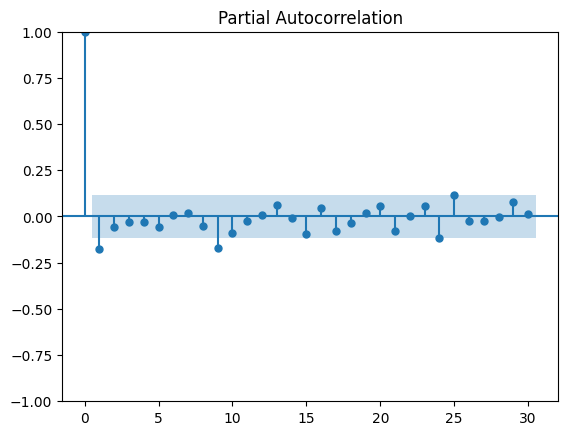

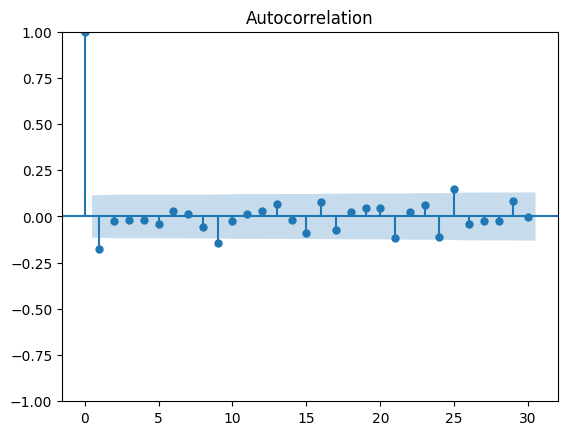

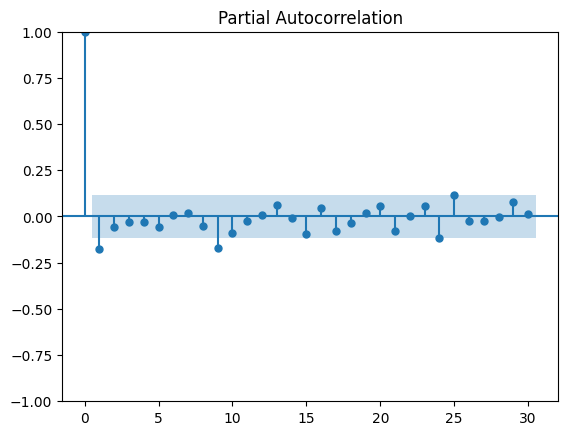

In [12]:
# (4) Prueba ADF para la serie original
adf_result = adfuller(df['Valor'])
print(f"ADF p-valor: {adf_result[1]:.4f}")
# Como el p-value es alto (> 0.05), la serie NO es estacionaria. Aplicamos 1 diferencia:
datos_diff = df['Valor'].diff().dropna()

# (5) Graficar ACF y PACF (visualización, no se muestra aquí)
# La ACF/PACF ayudan a determinar p y q【10†L7-L11】.
plot_acf(datos_diff, lags=30)   # función de autocorrelación
plot_pacf(datos_diff, lags=30)  # función de autocorrelación parcial

Supongamos (p,d,q)=(1,1,1) basado en ACF/PACF, y (P,D,Q)=(1,1,1) para estacionalidad semanal. Como no tenemos fines de semana en los datos, una estacionalidad semanal es representado por s = 5, no s = 7

In [13]:
modelo_s5 = SARIMAX(df['Valor'], order=(1,1,1), seasonal_order=(1,1,1,5), exog=df['holiday'])
res_s5 = modelo_s5.fit(disp=False)
print(res_s5.summary())


/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Valor   No. Observations:                  294
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                 217.226
Date:                           Wed, 04 Mar 2026   AIC                           -422.451
Time:                                   12:12:29   BIC                           -400.474
Sample:                                        0   HQIC                          -413.644
                                           - 294                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       -0.0372      0.035     -1.068      0.285      -0.105       0.031
ar.L1          0.3583      0.237      1.510

/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Ahora probamos de nuevo, pero con s = 20 (estacionalidad mensual)

In [14]:
# (7) Ajustar SARIMAX con s=20
# Por simplicidad, usamos de nuevo (p,d,q)=(1,1,1) y (P,D,Q)=(1,1,1,20)
modelo_s20 = SARIMAX(df['Valor'], order=(1,1,1), seasonal_order=(1,1,1,20), exog=df[['holiday']])
res_s20 = modelo_s20.fit(disp=False)
print(res_s20.summary())


/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Valor   No. Observations:                  294
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 20)   Log Likelihood                 186.956
Date:                            Wed, 04 Mar 2026   AIC                           -361.912
Time:                                    12:12:33   BIC                           -340.255
Sample:                                         0   HQIC                          -353.219
                                            - 294                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       -0.0445      0.031     -1.433      0.152      -0.105       0.016
ar.L1          0.2167      0.328   

In [15]:
print(f"AIC (s=5): {res_s5.aic:.1f}")
print(f"AIC (s=20): {res_s20.aic:.1f}")


AIC (s=5): -422.5
AIC (s=20): -361.9


Con estas pruebas, podemos definir que un valor de s = 5 va a ser mejor para estos datos.

Otro fenómeno que vimos es que nuestra variable exógena realmente no está influenciando demasiado los valores de las predicciones. Esto es probablemente debido a que los días festivos solo se manifiestan unas cuantas veces al año, y nuestro dataset apenas tiene un año de información, por lo que la variable probablemente no puede definir completamente bien el comportamiento de los mercados en estos momentos.

Ya que esto hace que la variable exógenea sea casi como un ruido solamente, decidimos no incluirla en la versión final. Es decir, este va a ser un modelo SARIMA solamente.

## <font color= #70A9E0> &ensp; • **Orden P, Q** </font>

El sábado empezó una nueva guerra en Irán, y en estos días la tasa de cambio entre el peso y el dólar ha estado subiendo, de forma que no había hecho en los últimos meses. Según el mismo presidente estadounidense, [esta es una guerra que no va a acabar pronto](https://www.nytimes.com/2026/03/02/us/politics/trump-war-iran-israel.html), así que consideramos que este crecimiento va a seguir durante los próximos días, incluyendo nuestro periodo de prueba.

Debido a esto, proponemos **dos** modelos finales distintos. El primero va a tener un orden **(1,1,1),(0,1,0,5)**, que genera predicciones más ambiciosas sobre el aumento de la tasa de cambio en la próxima semana. El segundo, con un orden **(1,1,1),(1,1,1,5)** va a ser más conservador, manteniendo la tendencia hacia abajo que presentan todos los datos, aunque de forma menos pronunciada para considerar el efecto de la guerra.

# <font color= #99C8F5> **Modelado** </font>

In [16]:
modelo_1 = SARIMAX(df['Valor'], order=(1,1,1), seasonal_order=(0,1,0,5))
resultado_1 = modelo_1.fit(disp=False)
print(resultado_1.summary())  # Resumen del ajuste (AIC, coeficientes, etc.)


                                     SARIMAX Results                                      
Dep. Variable:                              Valor   No. Observations:                  294
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 5)   Log Likelihood                 125.520
Date:                            Wed, 04 Mar 2026   AIC                           -245.040
Time:                                    12:12:33   BIC                           -234.051
Sample:                                         0   HQIC                          -240.636
                                            - 294                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0665      0.276      0.241      0.810      -0.475       0.608
ma.L1         -0.2616      0.277   

/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
# Predecir los próximos 9 días (5 al 13 de marzo de 2026)
pronostico_1 = resultado_1.get_forecast(steps=9)
pred_mean_1 = pronostico_1.predicted_mean

# Crear índice de fechas para el pronóstico (a partir del último día observado)
fechas_pred = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=9, freq='D')

# Crear DataFrame con Fecha y Pronóstico
df_pred_1 = pd.DataFrame({'Fecha': fechas_pred, 'Pronóstico': pred_mean_1.values})

# Exportar las predicciones a un archivo Excel
##df_pred_1.to_excel("predicciones_mar5_13_2026.xlsx", index=False)

/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [18]:
fig = go.Figure()
# Serie histórica observada
fig.add_trace(go.Scatter(x=df.index, y=df['Valor'], mode='lines', name='Observado'))
# Pronóstico futuro
fig.add_trace(go.Scatter(x=df_pred_1['Fecha'], y=df_pred_1['Pronóstico'], mode='lines', name='Pronóstico'))
fig.update_layout(title='Tipo de cambio MXN/USD (FIX): Observado vs Pronóstico',
                  xaxis_title='Fecha', yaxis_title='Tipo de cambio (FIX)')
fig.show()

In [19]:
modelo_2 = SARIMAX(df['Valor'], order=(1,1,1), seasonal_order=(1,1,1,5))
resultado_2 = modelo_2.fit(disp=False)
print(resultado_2.summary())  # Resumen del ajuste (AIC, coeficientes, etc.)


/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Valor   No. Observations:                  294
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                 216.374
Date:                           Wed, 04 Mar 2026   AIC                           -422.748
Time:                                   12:12:33   BIC                           -404.433
Sample:                                        0   HQIC                          -415.409
                                           - 294                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3634      0.233      1.559      0.119      -0.094       0.820
ma.L1         -0.5374      0.224     -2.398

In [ ]:
# Predecir los próximos 9 días (5 al 13 de marzo de 2026)
pronostico_2 = resultado_2.get_forecast(steps=9)
pred_mean_2 = pronostico_2.predicted_mean

# Crear índice de fechas para el pronóstico (a partir del último día observado)
fechas_pred = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=9, freq='D')

# Crear DataFrame con Fecha y Pronóstico
df_pred_2 = pd.DataFrame({'Fecha': fechas_pred, 'Pronóstico': pred_mean_2.values})

/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/sofi/Documents/vscode/Examen1-MNLPP/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [21]:
fig = go.Figure()
# Serie histórica observada
fig.add_trace(go.Scatter(x=df.index, y=df['Valor'], mode='lines', name='Observado'))
# Pronóstico futuro
fig.add_trace(go.Scatter(x=df_pred_2['Fecha'], y=df_pred_2['Pronóstico'], mode='lines', name='Pronóstico'))
fig.update_layout(title='Tipo de cambio MXN/USD (FIX): Observado vs Pronóstico',
                  xaxis_title='Fecha', yaxis_title='Tipo de cambio (FIX)')
fig.show()

In [25]:
df_pred_1

,Fecha,Pronóstico
0,2026-03-05,17.639789
1,2026-03-06,17.603386
2,2026-03-07,17.732626
3,2026-03-08,18.106928
4,2026-03-09,17.928629
5,2026-03-10,18.023917
6,2026-03-11,17.987515
7,2026-03-12,18.116755
8,2026-03-13,18.491057


In [26]:
df_pred_2

,Fecha,Pronóstico
0,2026-03-05,17.517533
1,2026-03-06,17.507392
2,2026-03-07,17.487987
3,2026-03-08,17.475720
4,2026-03-09,17.446511
5,2026-03-10,17.441459
6,2026-03-11,17.436493
7,2026-03-12,17.425464
8,2026-03-13,17.429878


In [27]:
# Guardando datos en Excel

df_final = pd.DataFrame(
    {'modelo_1': df_pred_1['Pronóstico'],
     'modelo_2': df_pred_2['Pronóstico'],}
)
df_final.head()

,modelo_1,modelo_2
0,17.639789,17.517533
1,17.603386,17.507392
2,17.732626,17.487987
3,18.106928,17.475720
4,17.928629,17.446511


In [ ]:
df_final.to_excel("predicciones_mar5_13_2026.xlsx", index=False)